In [1]:
import pandas as pd
import numpy as np


In [2]:
# Load dataset
df = pd.read_csv("raw.csv")


In [3]:
# Basic structure
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (2000, 15)

Columns:
Index(['post_id', 'platform', 'content_type', 'topic', 'language', 'region',
       'post_datetime', 'hashtags', 'views', 'likes', 'comments', 'shares',
       'engagement_rate', 'sentiment_score', 'is_viral'],
      dtype='str')


In [4]:
print("\nData Types:")
print(df.dtypes)


Data Types:
post_id                str
platform               str
content_type           str
topic                  str
language               str
region                 str
post_datetime          str
hashtags               str
views                int64
likes                int64
comments             int64
shares               int64
engagement_rate    float64
sentiment_score    float64
is_viral             int64
dtype: object


In [5]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
     post_id        platform content_type       topic language  region  \
0  SM_100000       Instagram         text      Sports       ur      UK   
1  SM_100001       Instagram     carousel      Sports       ur  Brazil   
2  SM_100002  YouTube Shorts        video  Technology       ur      UK   
3  SM_100003               X         text    Politics       ur      US   
4  SM_100004  YouTube Shorts         text   Education       es      US   

         post_datetime                         hashtags    views   likes  \
0  2024-12-10 00:00:00              #tech #funny #music  2319102  122058   
1  2024-10-13 00:00:00  #news #fyp #funny #ai #trending  2538464  110368   
2  2024-05-03 00:00:00                        #ai #news  1051176   87598   
3  2024-08-04 00:00:00                       #ai #funny  5271440  329465   
4  2024-03-28 00:00:00     #news #ai #viral #funny #fyp  3186256  199141   

   comments  shares  engagement_rate  sentiment_score  is_viral  
0     15800     8

In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
post_id            0
platform           0
content_type       0
topic              0
language           0
region             0
post_datetime      0
hashtags           0
views              0
likes              0
comments           0
shares             0
engagement_rate    0
sentiment_score    0
is_viral           0
dtype: int64


In [7]:
df = df.drop_duplicates()

In [8]:
print(df.describe())

              views          likes      comments        shares  \
count  2.000000e+03    2000.000000   2000.000000   2000.000000   
mean   4.284860e+06  245329.244000  24786.929000  49936.981500   
std    3.246193e+06  145032.423582  14433.288364  29012.818697   
min    4.380000e+03     292.000000     14.000000    127.000000   
25%    1.652742e+06  118903.750000  12337.750000  25698.750000   
50%    3.469408e+06  239831.000000  24519.500000  50212.000000   
75%    6.348078e+06  372323.500000  37116.250000  75433.000000   
max    1.437179e+07  499983.000000  49989.000000  99977.000000   

       engagement_rate  sentiment_score     is_viral  
count      2000.000000      2000.000000  2000.000000  
mean          0.157852        -0.000566     0.699000  
std           0.535457         0.574911     0.458807  
min           0.035700        -1.000000     0.000000  
25%           0.057975        -0.507000     0.000000  
50%           0.084500         0.001000     1.000000  
75%           0.1425

In [14]:
print(df["views"].describe())

count    2.000000e+03
mean     4.284860e+06
std      3.246193e+06
min      4.380000e+03
25%      1.652742e+06
50%      3.469408e+06
75%      6.348078e+06
max      1.437179e+07
Name: views, dtype: float64


In [13]:
from scipy.stats import skew, kurtosis

print("Skewness (views):", skew(df["views"]))
print("Kurtosis (views):", kurtosis(df["views"]))

Skewness (views): 0.8343720893434595
Kurtosis (views): -0.068955994054968


In [15]:
plt.hist(df["views"], bins=50)
plt.ticklabel_format(style='plain', axis='x')
plt.title("Distribution of Views")
plt.xlabel("Views")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.show()

NameError: name 'plt' is not defined

In [ ]:
from scipy.stats import skew

print("Skewness (views):", skew(df["views"]))
print("Skewness (log_views):", skew(df["log_views"]))

Skewness (views): 0.8343720893434595
Skewness (log_views): -1.4164943826287228


In [ ]:
Y = df["views"]

In [ ]:
candidate_features = [
    "likes",
    "shares",
    "comments",
    "sentiment_score"
]

In [ ]:
from scipy.stats import skew, kurtosis

for col in candidate_features:
    print(f"{col}")
    print("  Skewness :", skew(df[col]))
    print("  Kurtosis :", kurtosis(df[col]))
    print()

likes
  Skewness : 0.0714361006814715
  Kurtosis : -1.197814565451044

shares
  Skewness : 0.00828027811276957
  Kurtosis : -1.1991051540468671

comments
  Skewness : 0.015082043885337367
  Kurtosis : -1.178920861049205

sentiment_score
  Skewness : -0.0019276653011383572
  Kurtosis : -1.1985237172579897



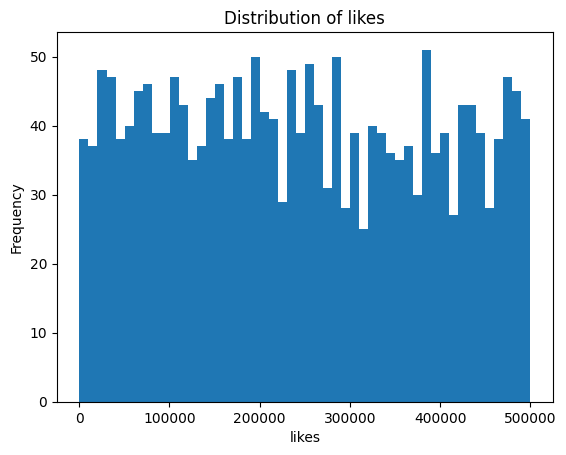

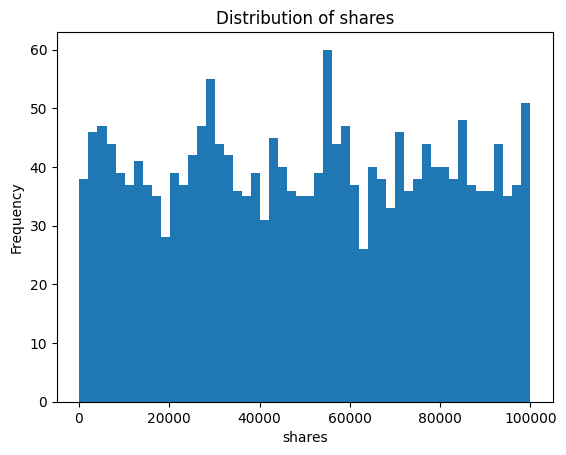

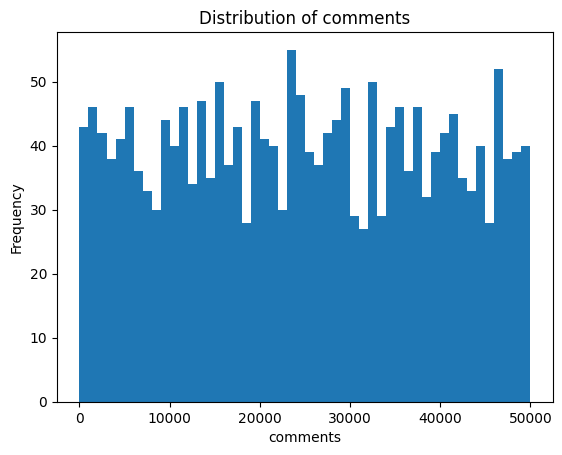

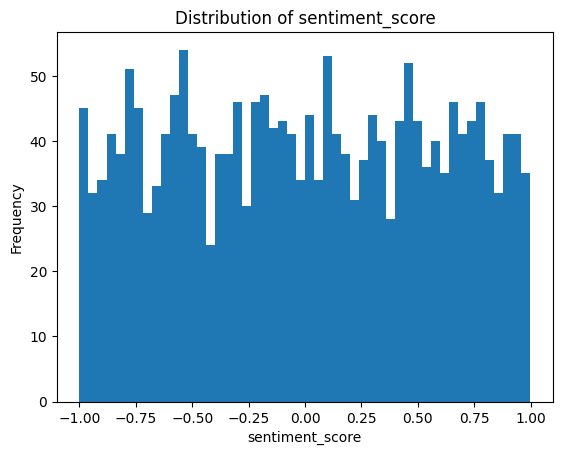

In [ ]:
import matplotlib.pyplot as plt

for col in candidate_features:
    plt.figure()
    plt.hist(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

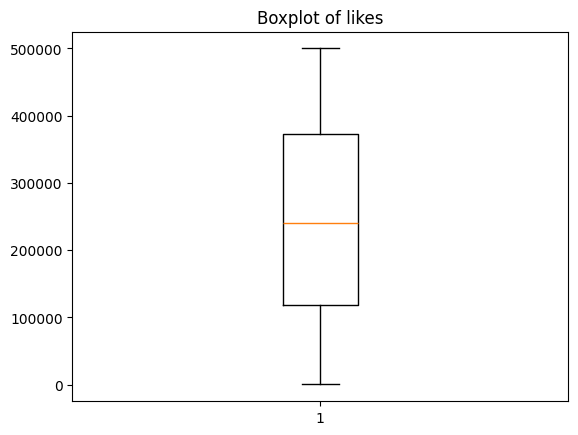

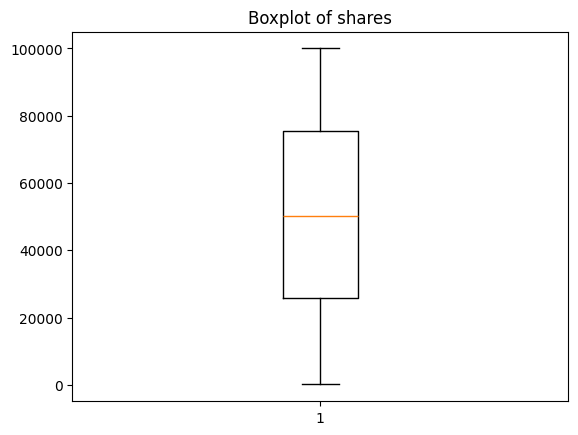

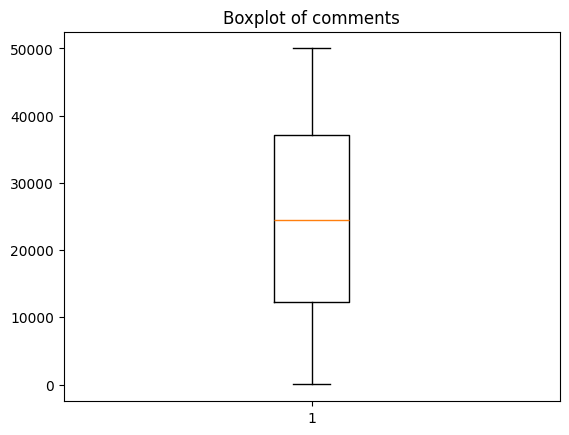

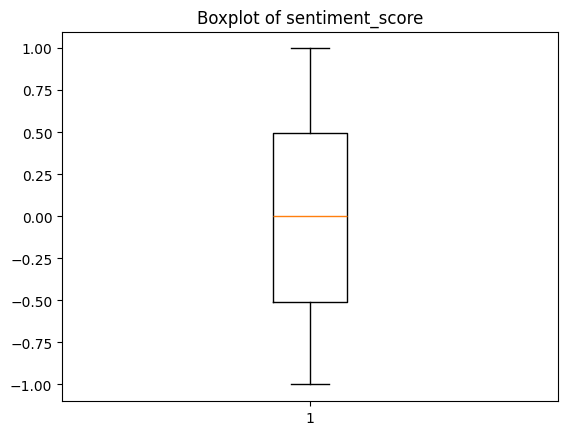

In [ ]:
for col in candidate_features:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
cols = ["views"] + candidate_features
corr_matrix = df[cols].corr()

print(corr_matrix)

                    views     likes    shares  comments  sentiment_score
views            1.000000  0.774188 -0.013583 -0.019789         0.032827
likes            0.774188  1.000000 -0.004144 -0.020205         0.040277
shares          -0.013583 -0.004144  1.000000  0.007950        -0.003124
comments        -0.019789 -0.020205  0.007950  1.000000        -0.005790
sentiment_score  0.032827  0.040277 -0.003124 -0.005790         1.000000


In [ ]:
from scipy.stats import pearsonr

results = []

for feature in candidate_features:
    corr, p_value = pearsonr(df[feature], df["views"])
    results.append((feature, corr, p_value))

# Display nicely
for feature, corr, p_value in results:
    print(f"{feature:15} | Correlation: {corr:.4f} | P-value: {p_value:.4f}")

likes           | Correlation: 0.7742 | P-value: 0.0000
shares          | Correlation: -0.0136 | P-value: 0.5438
comments        | Correlation: -0.0198 | P-value: 0.3764
sentiment_score | Correlation: 0.0328 | P-value: 0.1422


In [ ]:
results_sorted = sorted(results, key=lambda x: abs(x[1]), reverse=True)

print("\nRanked Features (by strength):")
for feature, corr, p_value in results_sorted:
    print(f"{feature:15} | Correlation: {corr:.4f} | P-value: {p_value:.4f}")


Ranked Features (by strength):
likes           | Correlation: 0.7742 | P-value: 0.0000
sentiment_score | Correlation: 0.0328 | P-value: 0.1422
comments        | Correlation: -0.0198 | P-value: 0.3764
shares          | Correlation: -0.0136 | P-value: 0.5438


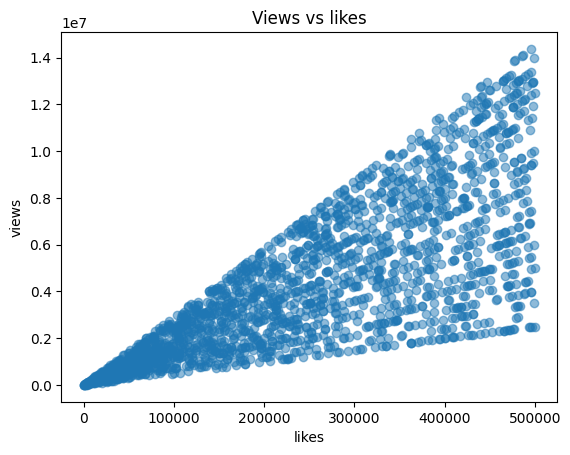

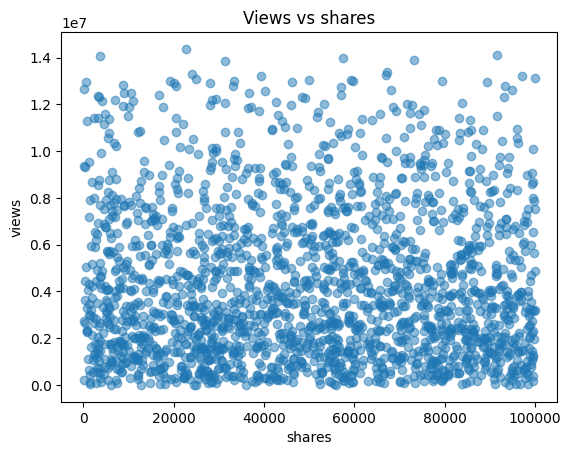

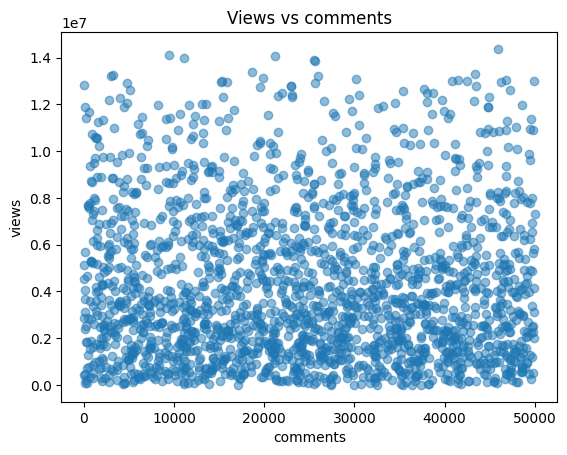

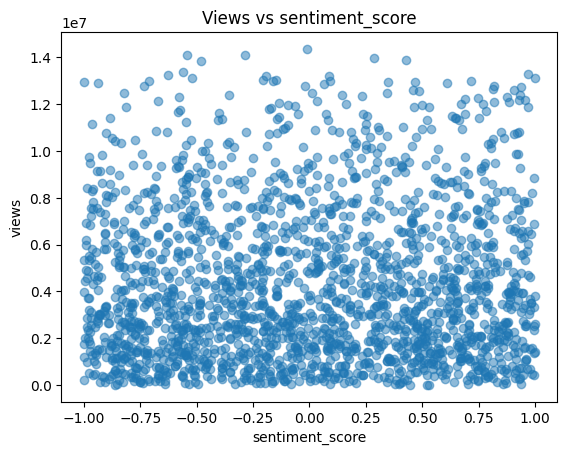

In [ ]:
import matplotlib.pyplot as plt

reaction_vars = ["likes", "shares", "comments", "sentiment_score"]

for var in reaction_vars:
    plt.figure()
    plt.scatter(df[var], df["views"], alpha=0.5)
    plt.xlabel(var)
    plt.ylabel("views")
    plt.title(f"Views vs {var}")
    plt.show()

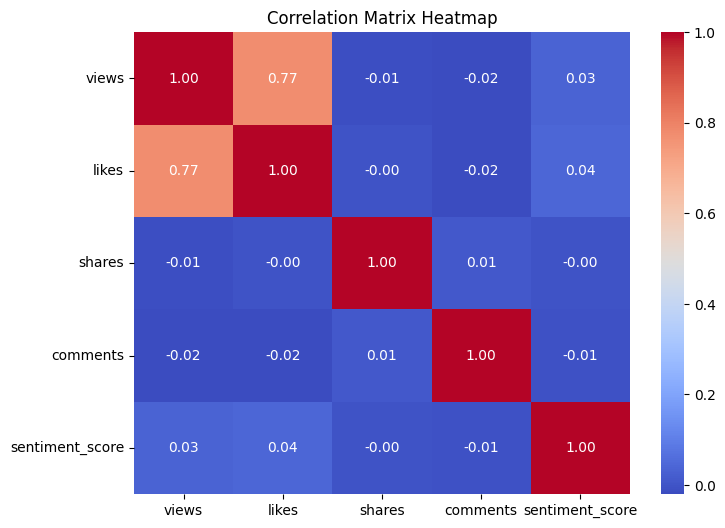

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["views", "likes", "shares", "comments", "sentiment_score"]
corr_matrix = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()